In [1]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

In [2]:
file_path = "processed_timeseries_table_timeseries_table (2).csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "lsobieski/processed-thermostat-data",
    file_path,
)

In [3]:
# Preprocess

df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Date"] = df["Timestamp"].dt.date

df["CumulativeRuntime"] = (
    pd.to_timedelta(df["CumulativeRuntime"], errors="coerce")
      .dt.total_seconds()
)

In [4]:
# Create daily runtime dataset

daily_data = df.groupby("Date").agg(
    runtime_start=("CumulativeRuntime", "first"),
    runtime_end=("CumulativeRuntime", "last")
)

daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]

daily_data = daily_data.dropna()

In [5]:
# Naive Model
# Predict today's runtime using yesterday's runtime

daily_data["naive_pred"] = daily_data["daily_runtime"].shift(1)

# remove first row (no previous day)
daily_data = daily_data.dropna()

pred_df = daily_data[["daily_runtime", "naive_pred"]].copy()

pred_df = pred_df.rename(columns={
    "daily_runtime": "y_true",
    "naive_pred": "y_pred"
})

pred_df = pred_df.reset_index()

In [6]:
# Evaluation Metrics

y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

In [7]:
def mape(y_true, y_pred, eps=1e-8):
    return 100 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))


def smape(y_true, y_pred, eps=1e-8):
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / denom)

In [8]:
mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

metrics = pd.Series({
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs
})

print("\nNaive Model Evaluation\n")
print(metrics)


Naive Model Evaluation

MSE                  4.241366e-10
RMSE                 2.059458e-05
MAE                  1.276464e-05
MedianAE             6.009500e-06
MaxAE                8.305300e-05
MAPE (%)             1.060952e+04
sMAPE (%)            6.885047e+01
R2                   2.736238e-01
ExplainedVariance    2.736242e-01
dtype: float64


<Axes: title={'center': 'Naive Model: Actual vs Predicted Daily Runtime'}, xlabel='Date'>

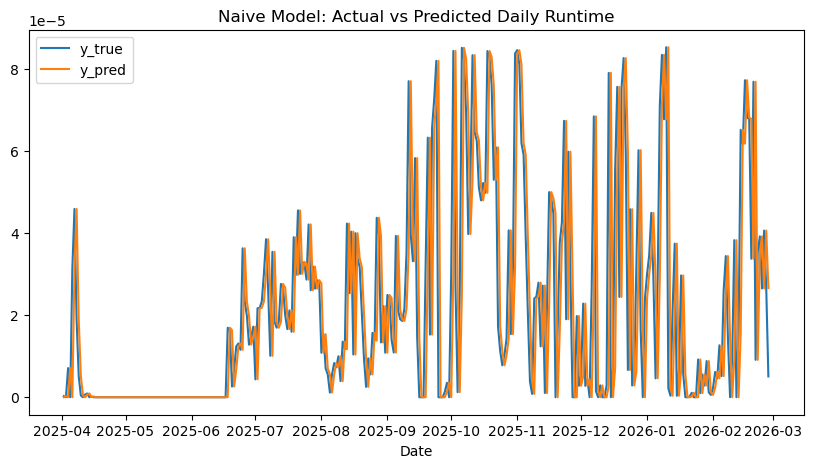

In [9]:
pred_df.set_index("Date")[["y_true", "y_pred"]].plot(
    title="Naive Model: Actual vs Predicted Daily Runtime",
    figsize=(10,5)
)